# 02. Sensitivity Analysis

Sensitivity of the three metrics to the six circuit parameters (Fig. 6E),

$$S = \frac{p}{M}\frac{dM}{dp} = \frac{d\log M}{d\log p}$$

the percentage change in the metric per 1% change in the parameter. Each parameter is swept individually over 20 logarithmically spaced values while the others stay at the baseline set of Fig. 6E ($a = b = f = g = 1$, $d = 2$, $c = 100$).

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add package source to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
# DynamicModel_Package lives in the repository's libs/ directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'libs')))

FIGURE_DIR = os.path.abspath(os.path.join(os.getcwd(), '../figures'))
RESULT_DIR = os.path.abspath(os.path.join(os.getcwd(), '../data/results'))
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

from circuit_to_target.model import PARAMETERS_FIG6
from circuit_to_target.metrics import pulse_amplitude, refractory_period, threshold
from circuit_to_target.sensitivity import (PARAMETER_COLORS, PARAMETER_NAMES,
                                           SWEEP_RANGES, sensitivity_table,
                                           sweep_metric)

print("baseline:", PARAMETERS_FIG6)
for metric, ranges in SWEEP_RANGES.items():
    print(f"{metric:16s}", {k: v for k, v in ranges.items()})

baseline: {'a': 1.0, 'b': 1.0, 'c': 100.0, 'd': 2.0, 'f': 1.0, 'g': 1.0}
threshold        {'a': (0.1, 10.0), 'c': (20.0, 500.0), 'd': (0.01, 20.0)}
pulse_amplitude  {'a': (0.5, 2.5), 'b': (0.1, 5.0), 'c': (20.0, 500.0), 'd': (0.01, 10.0), 'f': (0.1, 2.5), 'g': (0.1, 10.0)}
refractory       {'a': (0.5, 2.5), 'b': (0.1, 5.0), 'c': (20.0, 500.0), 'd': (0.01, 10.0), 'f': (2.5, 10.0), 'g': (0.1, 2.0)}


## Metric values at the baseline

In [2]:
print(f"threshold         = {threshold(**{k: PARAMETERS_FIG6[k] for k in ('a', 'c', 'd')}):.4f}")
print(f"pulse amplitude   = {pulse_amplitude(PARAMETERS_FIG6):.4f}")
print(f"refractory period = {refractory_period(PARAMETERS_FIG6):.4f}")

threshold         = 2.0417
pulse amplitude   = 50.9290
refractory period = 4.8300


## Sensitivity table

In [3]:
table = sensitivity_table()
table.to_csv(os.path.join(RESULT_DIR, 'sensitivity_table.csv'))
print(table.round(4).to_string())

                      a       b       c       d       f       g
threshold       -1.0698  0.0000 -0.0359  1.0425  0.0000  0.0000
pulse_amplitude  1.7339 -0.8129  1.1059 -0.1846 -0.9675  0.2455
refractory      -0.0358 -0.0013 -0.0277  0.0092 -0.0122 -0.9709


The pulse amplitude is measured from an initial condition of `X_threshold + 1`. Repeating it from `1.1 * X_threshold` changes the amplitude row: close to threshold the peak is set by the distance to threshold rather than by the carrying capacity, so the dependence on `c` all but vanishes.

In [4]:
table_alt = sensitivity_table(x0_rule='1.1*threshold')
table_alt.to_csv(os.path.join(RESULT_DIR, 'sensitivity_table_1.1threshold.csv'))
print(table_alt.round(4).to_string())

                      a       b       c       d       f       g
threshold       -1.0698  0.0000 -0.0359  1.0425  0.0000  0.0000
pulse_amplitude  1.8923 -0.9045  0.0080  1.1007 -1.1695  0.8132
refractory      -0.0358 -0.0013 -0.0277  0.0092 -0.0122 -0.9709


## Fig. 6E - sensitivity bar charts

Bars show |S|; the sign of each sensitivity is printed above the axis.

Threshold for activation: a=-1.0698, b=+0.0000, c=-0.0359, d=+1.0425, f=+0.0000, g=+0.0000
Pulse amplitude: a=+1.7339, b=-0.8129, c=+1.1059, d=-0.1846, f=-0.9675, g=+0.2455
Refractory period: a=-0.0358, b=-0.0013, c=-0.0277, d=+0.0092, f=-0.0122, g=-0.9709


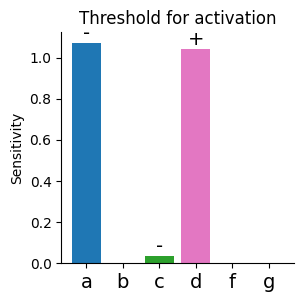

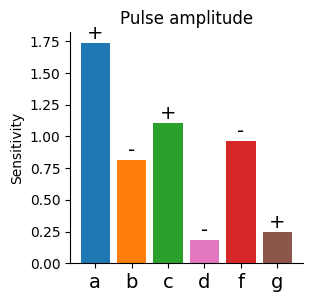

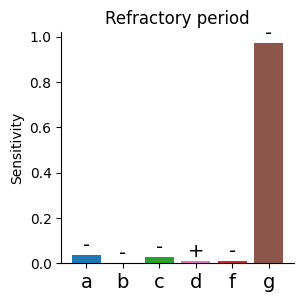

In [5]:
panels = [('threshold', 'Threshold for activation', 'thresh_sensitivity'),
          ('pulse_amplitude', 'Pulse amplitude', 'xmax_sensitivity'),
          ('refractory', 'Refractory period', 'refrac_sensitivity')]

for row, title, stem in panels:
    values = table.loc[row, list(PARAMETER_NAMES)].values.astype(float)

    fig, ax = plt.subplots(figsize=(3, 3))
    ax.bar(list(PARAMETER_NAMES), np.abs(values), color=list(PARAMETER_COLORS))
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Sensitivity')
    ax.set_title(title, fontsize=12)
    for label in ax.get_xticklabels():
        label.set_fontsize(14)

    # Mark the sign of each non-negligible sensitivity.
    for i, value in enumerate(values):
        if abs(value) > 1e-3:
            ax.text(i, abs(value), '+' if value > 0 else '-', ha='center',
                    va='bottom', fontsize=14)

    fig.savefig(os.path.join(FIGURE_DIR, f'{stem}.png'), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(FIGURE_DIR, f'{stem}.pdf'), dpi=600, bbox_inches='tight')
    print(f"{title}: " + ", ".join(f"{n}={v:+.4f}" for n, v in zip(PARAMETER_NAMES, values)))

## Underlying sweeps

The metric against each parameter it depends on, for inspection.

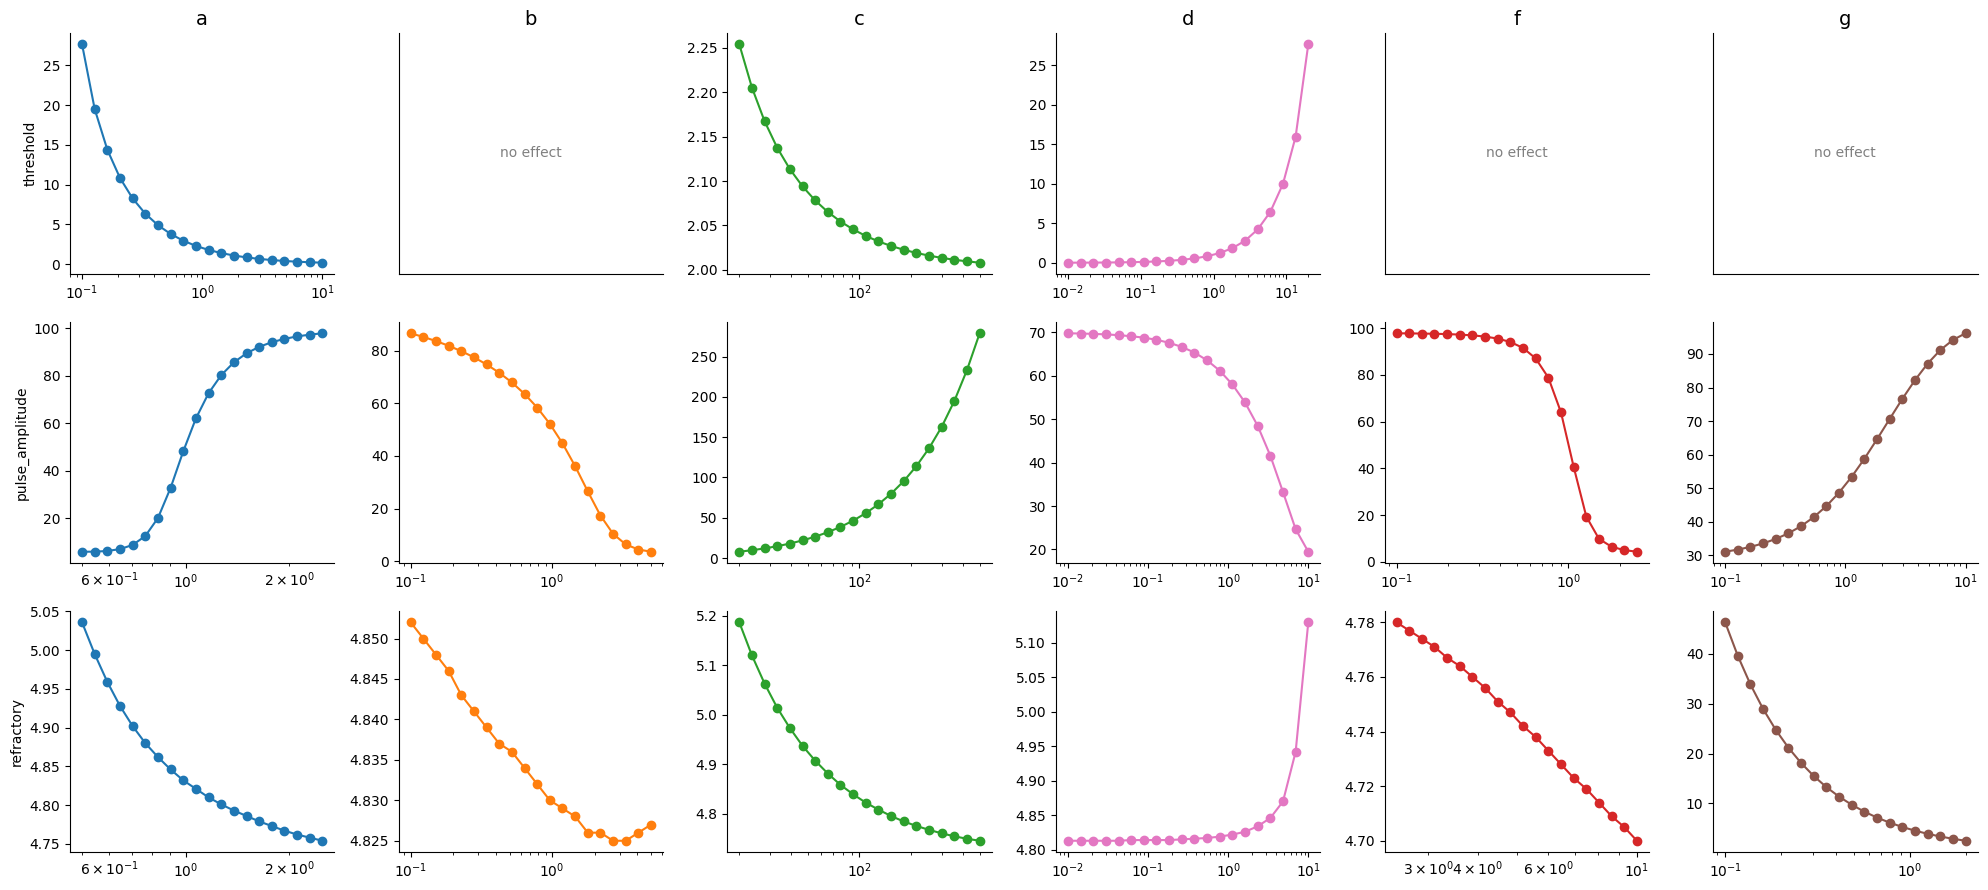

In [6]:
metrics = {'threshold': threshold, 'pulse_amplitude': pulse_amplitude,
           'refractory': refractory_period}

fig, axs = plt.subplots(nrows=3, ncols=6, figsize=(20, 9))
for r, (name, metric) in enumerate(metrics.items()):
    for k, parameter in enumerate(PARAMETER_NAMES):
        ax = axs[r, k]
        if parameter in SWEEP_RANGES[name]:
            low, high = SWEEP_RANGES[name][parameter]
            values, metric_values = sweep_metric(metric, parameter, low, high)
            ax.plot(values, metric_values, 'o-', color=PARAMETER_COLORS[k])
            ax.set_xscale('log')
        else:
            ax.text(0.5, 0.5, 'no effect', ha='center', va='center',
                    transform=ax.transAxes, color='grey')
            ax.set_xticks([])
            ax.set_yticks([])
        ax.spines[['top', 'right']].set_visible(False)
        if r == 0:
            ax.set_title(parameter, fontsize=14)
        if k == 0:
            ax.set_ylabel(name)
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, 'sensitivity_sweeps.png'), dpi=200, bbox_inches='tight')